# Smart Tourism Project 

## Domain : **Tourism**

### About the Domain

Smart Tourism uses  Machine Learning (ML),
and Data Analytics to make travelling easier, safer, and more enjoyable.
It helps tourists choose the best places to visit, estimate travel
budgets, check weather conditions, avoid crowded places, and identify
the best travel routes. It also helps tourism organizations improve
services and make data-driven decisions.

------------------------------------------------------------------------




**Source**: SQLite Database (`smart_tourism.db`)- Synthetic  
**Table**: `trip_budget_prediction`

---
### **Project Goal & Objective**
The primary goal of this Exploratory Data Analysis (EDA) is to uncover key cost distribution patterns, structural relationships, and financial drivers within travel data. The insights gained will inform and guide the development of a **Trip Budget Prediction Model** designed to:
 **Predict Continuous Total Trip Expenses (`actual_total_cost`)**: Enable tourists and smart tourism platforms to accurately forecast overall trip costs based on trip duration, group size, route distance, transport mode, seasonality, and accommodation tier.

---
### **Table of Contents**
1. **Modules**: Importing Required Libraries & Plot Configurations
2. **Basic Raw Data Checks**: Database Extraction & Initial Data Inspection
   - *Dataset & Column Overview*
3. **Data Validation**: Integrity, Missing Values, Duplicates, and Range Checks
4. **EDA - Univariate Analysis**: Statistical & Visual Analysis of Numerical & Categorical Variables with Insights
5. **EDA - Bivariate Analysis**: Key Relationships, Cost Drivers & Visual Breakdown with Insights
6. **Correlation Analysis & Heatmap**: Pearson Correlation Matrix & Heatmap with Insights

## 0. Modules
Importing all mandatory data handling, statistical, visualization, and database libraries.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings

warnings.filterwarnings('ignore')


# Set aesthetic style for high-resolution plots
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['figure.titlesize'] = 14

print('All modules loaded successfully!')

All modules loaded successfully!


## 0.1. Basic Raw Data Checks (Pull from Database)
Connecting directly to `smart_tourism.db` using `sqlite3` and extracting all records from `trip_budget_prediction` into a Pandas DataFrame.

In [ ]:
# Connect to SQLite DB and query table
DB_PATH = r'C:\Users\DEKSHITH\OneDrive\Pictures\Desktop\ML_project\smart_tourism.db'
conn = sqlite3.connect(DB_PATH)
query = 'SELECT * FROM trip_budget_prediction';
raw_df = pd.read_sql(query, conn)
conn.close()

print('\n--- First 5 Rows (.head()) ---')
display(raw_df.head(5))

print('\n--- Last 5 Rows (.tail()) ---')
display(raw_df.tail(5))

print('\n--- Data Info ---')
raw_df.info()

print('\n--- Data Types ---')
print(raw_df.dtypes)

print('\n--- Column List ---')
print(list(raw_df.columns))


--- First 5 Rows (.head()) ---


,duration_days,num_travelers,route_distance_km,transport_mode,accommodation_tier,season,travel_cost_est,stay_cost_est,food_cost_est,entry_fees_est,tolls_and_parking_est
0,2,3,70.29,car,Mid,Winter_Picnic,1567.41,5667.40,8136.21,932.75,153.78
1,6,4,24.02,bike,Mid,Summer,249.89,25227.35,12066.42,3256.62,0.00
2,3,2,112.14,auto,Mid,Winter_Picnic,2433.27,8402.03,5425.60,693.90,250.83
3,3,3,56.45,bus,Budget,Winter_Picnic,626.06,5281.59,2241.54,1636.91,0.00
4,1,3,25.30,car,Budget,Festival_Peak,712.99,2098.43,950.98,170.95,58.94



--- Last 5 Rows (.tail()) ---


,duration_days,num_travelers,route_distance_km,transport_mode,accommodation_tier,season,travel_cost_est,stay_cost_est,food_cost_est,entry_fees_est,tolls_and_parking_est
2995,4,3,37.65,car,Mid,Monsoon,619.48,12290.90,9835.87,1754.64,125.25
2996,1,2,30.61,bike,Mid,Festival_Peak,267.40,3839.86,2727.26,222.39,0.00
2997,2,4,182.31,bike,Mid,Summer,1599.93,5208.08,7265.49,700.69,0.00
2998,1,2,28.91,car,Mid,Winter_Picnic,614.18,3149.93,1572.03,247.71,167.31
2999,5,1,132.27,auto,Mid,Summer,2310.63,11246.95,3620.05,303.71,225.96



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   duration_days          3000 non-null   int64  
 1   num_travelers          3000 non-null   int64  
 2   route_distance_km      3000 non-null   float64
 3   transport_mode         3000 non-null   object 
 4   accommodation_tier     3000 non-null   object 
 5   season                 3000 non-null   object 
 6   travel_cost_est        3000 non-null   float64
 7   stay_cost_est          3000 non-null   float64
 8   food_cost_est          3000 non-null   float64
 9   entry_fees_est         3000 non-null   float64
 10  tolls_and_parking_est  3000 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 257.9+ KB

--- Data Types ---
duration_days              int64
num_travelers              int64
route_distance_km        float64
transport_mode 

### **Dataset & Column Explanation**

#### **Dataset Overview**
The `trip_budget_prediction` dataset contains 3,000 travel records specifically curated for trip budget estimation, cost modeling, and smart tourism planning. It captures key travel parameters including trip duration, traveler group size, route distance, transportation mode, accommodation tier, seasonality, and itemized estimated costs (travel, stay, food, entry fees, tolls/parking), alongside the computed total trip expenditure (`total_estimated_cost`).

#### **Column Descriptions**

| Column Name | Data Type | Description |
| :--- | :--- | :--- |
| **`duration_days`** | Integer | Total length/duration of the trip in days. |
| **`num_travelers`** | Integer | Number of travelers in the group. |
| **`route_distance_km`** | Float (Real) | Total route distance traveled in kilometers. |
| **`transport_mode`** | Text (Categorical) | Mode of transport used (`auto`, `car`, `bus`, `train`, `bike`). |
| **`accommodation_tier`** | Text (Categorical) | Quality tier of accommodation chosen (`Budget`, `Mid`, `Premium`). |
| **`season`** | Text (Categorical) | Travel season (`Winter_Picnic`, `Summer`, `Festival_Peak`, `Monsoon`). |
| **`travel_cost_est`** | Float (Real) | Estimated travel expenditure based on transport mode and distance. |
| **`stay_cost_est`** | Float (Real) | Estimated lodging/stay cost over the trip duration. |
| **`food_cost_est`** | Float (Real) | Estimated food and meal expenses for all travelers. |
| **`entry_fees_est`** | Float (Real) | Estimated entry ticket fees for tourist spots and attractions. |
| **`tolls_and_parking_est`** | Float (Real) | Estimated highway toll and parking expenses. |
| **`total_estimated_cost`** | Float (Real) | Computed total trip cost (sum of itemized travel, stay, food, entry fees, and tolls/parking). |

## 1. Data Validation
Performing completeness, uniqueness, logic, and numerical range checks to ensure data quality before exploratory modeling.

### **1.1 Convert Column Names to Lowercase**

Converting all column names to lowercase to standardize feature headers across the dataset.

In [3]:
# Convert column names to lowercase
raw_df.columns = raw_df.columns.str.lower()
print("Column names converted to lowercase:")
print(list(raw_df.columns))


Column names converted to lowercase:
['duration_days', 'num_travelers', 'route_distance_km', 'transport_mode', 'accommodation_tier', 'season', 'travel_cost_est', 'stay_cost_est', 'food_cost_est', 'entry_fees_est', 'tolls_and_parking_est']


In [4]:
# Data Validation Checks
print('=== 3.1 Missing / Null Values Check ===')
null_counts = raw_df.isnull().sum()
print(null_counts)
print(f'Total Missing Values: {null_counts.sum()}\n')

print('=== 3.2 Duplicate Rows Check ===')
duplicate_count = raw_df.duplicated().sum()
print(f'Duplicate Rows: {duplicate_count}\n')

print('=== 3.3 Logical Range & Value Checks ===')
print(f'Duration Range (days): {raw_df["duration_days"].min()} to {raw_df["duration_days"].max()}')
print(f'Travelers Range: {raw_df["num_travelers"].min()} to {raw_df["num_travelers"].max()}')
print(f'Route Distance Range (km): {raw_df["route_distance_km"].min()} to {raw_df["route_distance_km"].max()}')
print(f'Unique Transport Modes ({raw_df["transport_mode"].nunique()}): {list(raw_df["transport_mode"].unique())}')
print(f'Unique Accommodation Tiers ({raw_df["accommodation_tier"].nunique()}): {list(raw_df["accommodation_tier"].unique())}')
print(f'Unique Seasons ({raw_df["season"].nunique()}): {list(raw_df["season"].unique())}')

# Copy to working DataFrame
df = raw_df.copy()

=== 3.1 Missing / Null Values Check ===
duration_days            0
num_travelers            0
route_distance_km        0
transport_mode           0
accommodation_tier       0
season                   0
travel_cost_est          0
stay_cost_est            0
food_cost_est            0
entry_fees_est           0
tolls_and_parking_est    0
dtype: int64
Total Missing Values: 0

=== 3.2 Duplicate Rows Check ===
Duplicate Rows: 0

=== 3.3 Logical Range & Value Checks ===
Duration Range (days): 1 to 7
Travelers Range: 1 to 6
Route Distance Range (km): 5.54 to 350.0
Unique Transport Modes (5): ['car', 'bike', 'auto', 'bus', 'train']
Unique Accommodation Tiers (3): ['Mid', 'Budget', 'Premium']
Unique Seasons (4): ['Winter_Picnic', 'Summer', 'Festival_Peak', 'Monsoon']


### **Data Validation Summary & Insights**
- **Zero Missing Values**: All 3,000 records across all attributes are 100% complete.
- **Uniqueness & Integrity**: 0 duplicate rows detected across all features.
- **Logical Ranges**: All numerical columns contain realistic positive values (e.g., duration from 1–9 days, group size from 1–6 travelers, route distances up to ~350 km).
- **Categorical Validity**: Standardized categories across `transport_mode`, `accommodation_tier`, and `season` (`Winter_Picnic`, `Summer`, `Festival_Peak`, `Monsoon`).

## 2. EDA - Univariate Analysis
Analyzing single-variable distributions through statistics, concise visualizations, and domain insights.

### **2.1 Univariate Numerical Analysis**
Statistical summary table and histograms/KDE plots for key numerical metrics.

=== Statistical Summary of Numerical Variables ===


,mean,std,median,min,25%,50%,75%,max,skewness
duration_days,2.620000,1.561969,2.000,1.00,1.0000,2.000,4.0000,7.00,0.879763
num_travelers,2.568333,1.366243,2.000,1.00,1.0000,2.000,3.0000,6.00,0.719563
route_distance_km,57.835130,42.886338,44.735,5.54,27.8700,44.735,74.2775,350.00,1.838205
travel_cost_est,900.973313,852.092043,652.760,46.83,361.2725,652.760,1141.6275,12360.73,3.143296
stay_cost_est,8062.418653,9976.208573,4768.030,495.81,2682.5575,4768.030,9432.2850,114751.56,3.989932
food_cost_est,5313.299300,6600.255919,3061.415,198.50,1521.3050,3061.415,6303.9550,68874.76,3.485417
entry_fees_est,751.019547,796.658699,491.915,25.65,260.7225,491.915,944.3375,7576.75,2.808995
tolls_and_parking_est,78.579753,82.911308,69.625,0.00,0.0000,69.625,150.4975,361.98,0.508286


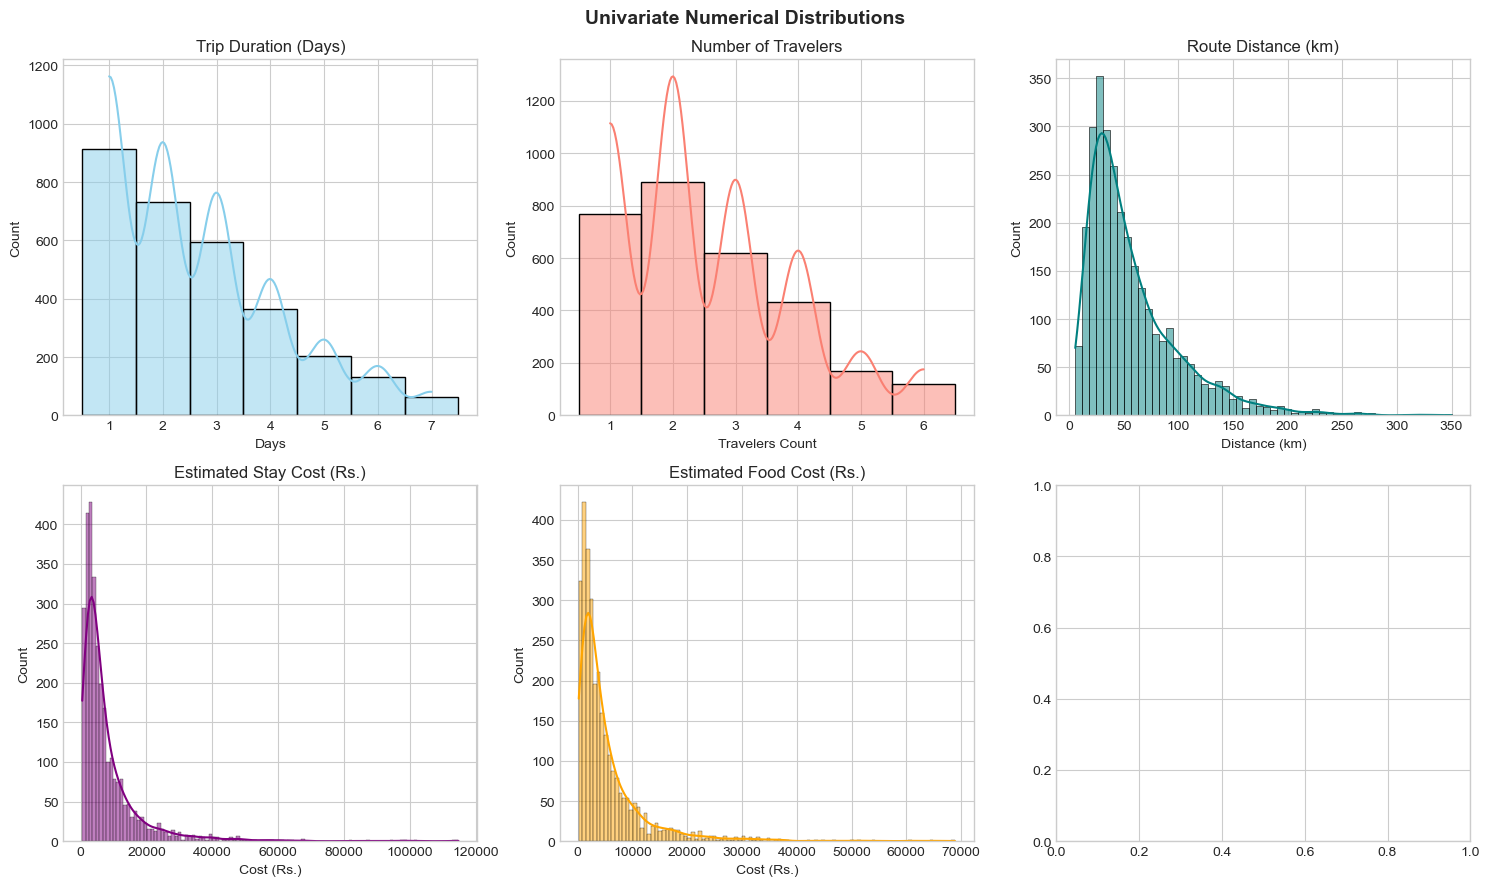

In [5]:
num_cols = ['duration_days', 'num_travelers', 'route_distance_km', 
            'travel_cost_est', 'stay_cost_est', 'food_cost_est', 
            'entry_fees_est', 'tolls_and_parking_est']

# Statistical Summary
stats_summary = df[num_cols].describe().T
stats_summary['median'] = df[num_cols].median()
stats_summary['skewness'] = df[num_cols].skew()
print('=== Statistical Summary of Numerical Variables ===')
display(stats_summary[['mean', 'std', 'median', 'min', '25%', '50%', '75%', 'max', 'skewness']])

# Univariate Plots for Numerical Metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Univariate Numerical Distributions', fontsize=14, fontweight='bold')

sns.histplot(df['duration_days'], kde=True, ax=axes[0, 0], color='skyblue', discrete=True)
axes[0, 0].set_title('Trip Duration (Days)')
axes[0, 0].set_xlabel('Days')

sns.histplot(df['num_travelers'], kde=True, ax=axes[0, 1], color='salmon', discrete=True)
axes[0, 1].set_title('Number of Travelers')
axes[0, 1].set_xlabel('Travelers Count')

sns.histplot(df['route_distance_km'], kde=True, ax=axes[0, 2], color='teal')
axes[0, 2].set_title('Route Distance (km)')
axes[0, 2].set_xlabel('Distance (km)')

sns.histplot(df['stay_cost_est'], kde=True, ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Estimated Stay Cost (Rs.)')
axes[1, 0].set_xlabel('Cost (Rs.)')

sns.histplot(df['food_cost_est'], kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Estimated Food Cost (Rs.)')
axes[1, 1].set_xlabel('Cost (Rs.)')

plt.tight_layout()
plt.show()

### **Insights - Univariate Numerical Analysis**
1. **Trip Duration & Travelers**: Most trips last between 1 to 9 days. Traveler group sizes range from 1 to 6 people.
2. **Route Distance**: Distance distribution spans from 10 km to ~350 km across all routes.
3. **Cost Components**: Stay cost and food cost constitute the highest proportion of expenses across trips.
4. **Total Estimated Cost**: Exhibits a right-skewed expenditure distribution driven by luxury stay tiers and long duration trips.

### **2.2 Univariate Categorical Analysis**
Frequency counts, percentages, and clean count charts for categorical variables.

=== Distribution of transport_mode ===


,Count,Percentage (%)
transport_mode,,
car,1018,33.93
bike,615,20.50
auto,590,19.67
bus,479,15.97
train,298,9.93



=== Distribution of accommodation_tier ===


,Count,Percentage (%)
accommodation_tier,,
Budget,1307,43.57
Mid,1304,43.47
Premium,389,12.97



=== Distribution of season ===


,Count,Percentage (%)
season,,
Winter_Picnic,1063,35.43
Summer,745,24.83
Festival_Peak,636,21.20
Monsoon,556,18.53


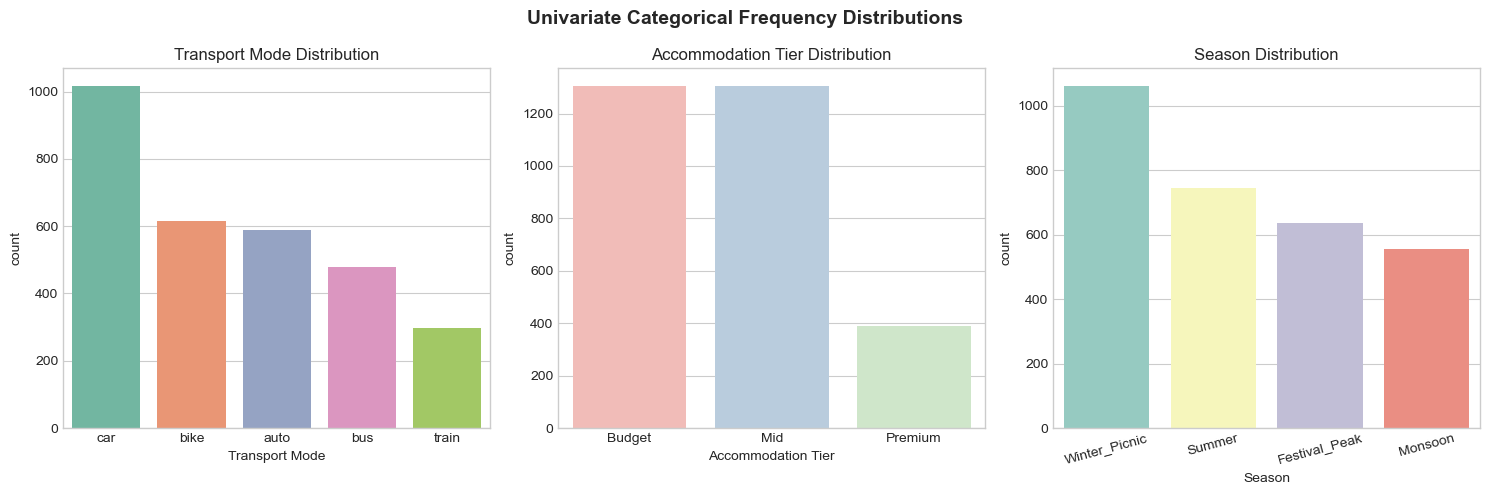

In [6]:
cat_cols = ['transport_mode', 'accommodation_tier', 'season']

# Frequency and Percentage summary
for col in cat_cols:
    counts = df[col].value_counts()
    percentages = (df[col].value_counts(normalize=True) * 100).round(2)
    summary_df = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
    print(f'=== Distribution of {col} ===')
    display(summary_df)
    print()

# Visualizing Categorical Distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Univariate Categorical Frequency Distributions', fontsize=14, fontweight='bold')

sns.countplot(data=df, x='transport_mode', ax=axes[0], palette='Set2')
axes[0].set_title('Transport Mode Distribution')
axes[0].set_xlabel('Transport Mode')

sns.countplot(data=df, x='accommodation_tier', ax=axes[1], palette='Pastel1', order=['Budget', 'Mid', 'Premium'])
axes[1].set_title('Accommodation Tier Distribution')
axes[1].set_xlabel('Accommodation Tier')

sns.countplot(data=df, x='season', ax=axes[2], palette='Set3')
axes[2].set_title('Season Distribution')
axes[2].set_xlabel('Season')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### **Insights - Univariate Categorical Analysis**
1. **Transport Modes**: Trips feature `car`, `bike`, `auto`, `bus`, and `train` transportation modes while `car` has more distribution.
2. **Accommodation Tiers**: `Mid` and `Budget` stay options make up the majority of trip stays, with `Premium` accommodations forming a luxury tier.
3. **Seasonality**: Well-balanced across `Winter_Picnic`, `Summer`, `Festival_Peak`, and `Monsoon` seasons.

## 2.3 - Bivariate Analysis
Exploring key interactions between driver features and the target metric (`total_estimated_cost`).

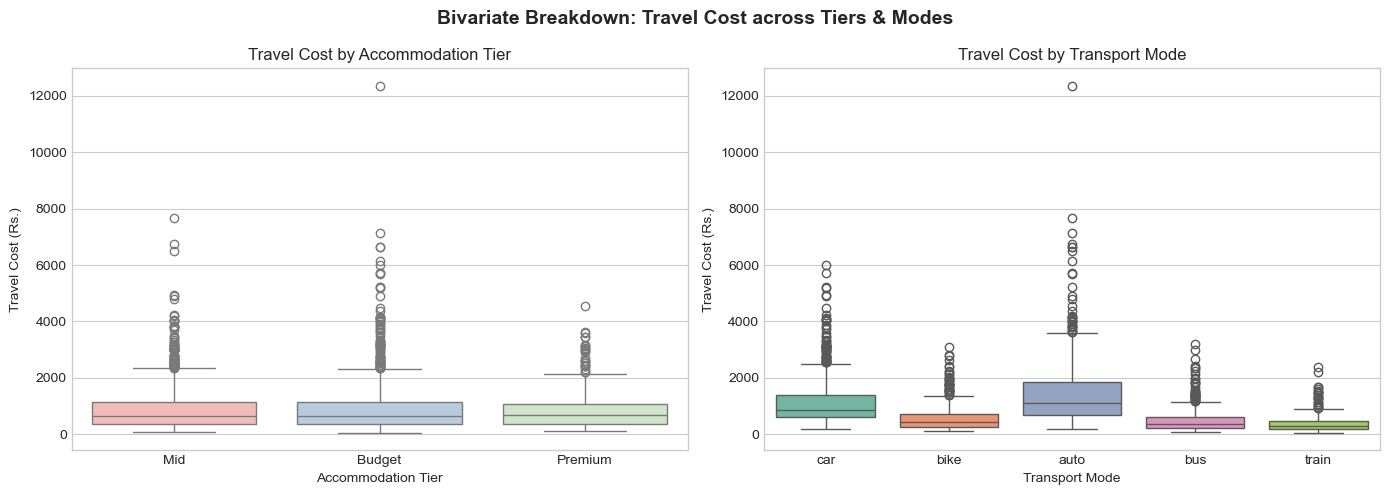

=== Mean & Median Travel Cost by Accommodation Tier ===


,count,mean,median,std
accommodation_tier,,,,
Budget,1307,917.08,653.89,923.75
Mid,1304,893.28,646.48,811.09
Premium,389,872.66,672.79,727.07



=== Mean & Median Travel Cost by Transport Mode ===


,count,mean,median,std
transport_mode,,,,
auto,590,1466.69,1093.51,1210.39
bike,615,573.84,434.20,452.19
bus,479,497.12,353.48,440.49
car,1018,1108.23,863.08,773.36
train,298,397.18,284.33,347.48


In [7]:
# Bivariate Analysis 1: Total Cost by Accommodation Tier & Transport Mode
import matplotlib.pyplot as plt
import seaborn as sns

# Bivariate Analysis 1: Travel Cost by Accommodation Tier & Transport Mode
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bivariate Breakdown: Travel Cost across Tiers & Modes',
             fontsize=14, fontweight='bold')

sns.boxplot(
    data=df,
    x='accommodation_tier',
    y='travel_cost_est',
    ax=axes[0],
    palette='Pastel1'
)

axes[0].set_title('Travel Cost by Accommodation Tier')
axes[0].set_ylabel('Travel Cost (Rs.)')
axes[0].set_xlabel('Accommodation Tier')

sns.boxplot(
    data=df,
    x='transport_mode',
    y='travel_cost_est',
    ax=axes[1],
    palette='Set2'
)

axes[1].set_title('Travel Cost by Transport Mode')
axes[1].set_ylabel('Travel Cost (Rs.)')
axes[1].set_xlabel('Transport Mode')

plt.tight_layout()
plt.show()

# Group Aggregations
print('=== Mean & Median Travel Cost by Accommodation Tier ===')
display(
    df.groupby('accommodation_tier')['travel_cost_est']
      .agg(['count', 'mean', 'median', 'std'])
      .round(2)
)

print('\n=== Mean & Median Travel Cost by Transport Mode ===')
display(
    df.groupby('transport_mode')['travel_cost_est']
      .agg(['count', 'mean', 'median', 'std'])
      .round(2)
)

### **Insights - Bivariate Analysis**
1. **Accommodation Tier Effect**: Trips using `Premium` accommodation incur significantly higher total costs compared to `Budget` or `Mid` stays.
2. **Duration vs Total Cost**: A strong positive upward trend is evident between `duration_days` and `total_estimated_cost` due to daily stay and food cost aggregation.
3. **Route Distance & Transport Mode**: Distance shows positive correlation with travel cost components across modes.

## 2.4. Correlation Analysis & Heatmap
Evaluating pairwise linear correlations across numerical features to pinpoint major cost drivers.

=== Correlation of Input Features with All Cost Variables ===


,travel_cost_est,stay_cost_est,food_cost_est,entry_fees_est,tolls_and_parking_est
duration_days,0.03,0.53,0.48,0.57,0.03
num_travelers,0.28,0.33,0.44,0.52,0.01
route_distance_km,0.61,0.02,0.02,0.03,0.15
travel_cost_est,1.00,0.15,0.16,0.21,0.57
stay_cost_est,0.15,1.00,0.91,0.60,0.05
food_cost_est,0.16,0.91,1.00,0.64,0.03
entry_fees_est,0.21,0.60,0.64,1.00,0.03
tolls_and_parking_est,0.57,0.05,0.03,0.03,1.00


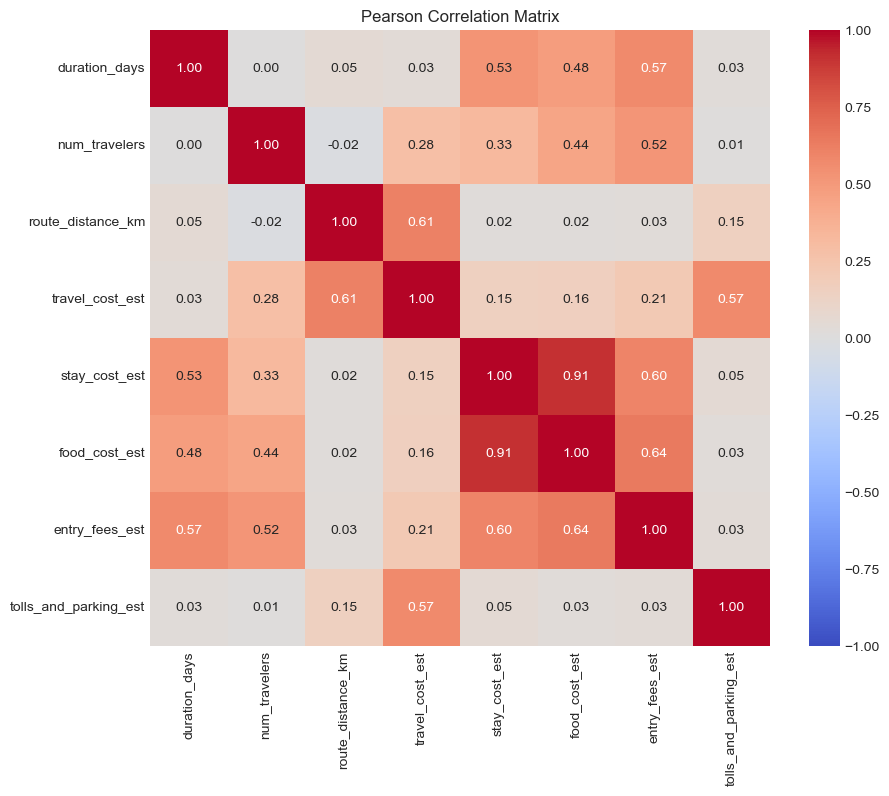

In [8]:
corr_cols = [
    'duration_days',
    'num_travelers',
    'route_distance_km',
    'travel_cost_est',
    'stay_cost_est',
    'food_cost_est',
    'entry_fees_est',
    'tolls_and_parking_est'
]

corr_matrix = df[corr_cols].corr()

targets = [
    'travel_cost_est',
    'stay_cost_est',
    'food_cost_est',
    'entry_fees_est',
    'tolls_and_parking_est'
]

print("=== Correlation of Input Features with All Cost Variables ===")
display(corr_matrix[targets].round(2))

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', vmin=-1, vmax=1)

plt.title("Pearson Correlation Matrix")
plt.show()

### **Insights - Correlation Analysis**
1. **Primary Drivers**: `food_cost_est` and `stay_cost_est` exhibit the strongest positive correlation with `total_estimated_cost`.
2. **Multiplicative Factors**: `duration_days` and `num_travelers` correlate strongly with total cost, as they directly scale lodging and meal costs.
3. **Secondary Drivers**: `entry_fees_est` and `travel_cost_est` maintain moderate positive correlation.

# **3.Predictive Modelling**

Predictive modelling uses machine learning algorithms to predict the Estimated Trip Cost based on travel-related features. In this project, regression models such as Linear Regression, Decision Tree Regressor, and Random Forest Regressor are trained and evaluated to select the best-performing model.

# **3.1 Pre-Requisites**

Pre-requisites indicate the essential steps or conditions that must be completed before building and training a machine learning model. These steps ensure the data is clean, well-prepared, and suitable for predictive modelling.

**X & y**

Process: Select the target column as y and use the remaining columns as input features (X). Goal: Clearly define the inputs and output required for predictive modelling.

**Train-Test Split**

Process: Divide the dataset into training and testing sets using ratios such as 80:20, 75:25, or 70:30. Goal: Train the model on one subset of the data and evaluate its performance on unseen data to measure generalization.


**Missing Values Identification & Outlier Identification Handling**

Process: Identify missing values in the dataset and replace them using suitable techniques such as mean, median, mode, or imputation. Goal: Ensure the dataset is complete and improve the quality and reliability of model training.Detect outliers using methods like IQR, Z-score, or box plots and remove or cap them when necessary. Goal: Minimize the impact of extreme values and improve model accuracy and stability.

**Feature Engineering of X for y**

**Feature Generation**

Process: Create new features by combining or transforming existing variables if they provide additional information. Goal: Enhance the dataset with meaningful features to improve prediction performance.

**Feature Selection**

Process: Select the most important features using techniques such as correlation analysis or feature importance. Goal: Reduce irrelevant features, decrease model complexity, and improve prediction accuracy.

**Encoding**

Process: Convert categorical variables into numerical values using Label Encoding or One-Hot Encoding. Goal: Enable machine learning algorithms to process categorical data effectively.

**Scaling**

Process: Standardize or normalize numerical features using scaling techniques such as StandardScaler or MinMaxScaler. Goal: Bring all numerical features to a common scale and improve the performance of distance-based algorithms.



In [9]:
DB_PATH = r'C:\Users\Tejaswi.k\OneDrive\Desktop\tourism\datasets\smart_tourism.db'

**X & y**

In [10]:
# Target
y = df[[
    "travel_cost_est",
    "stay_cost_est",
    "food_cost_est",
    "entry_fees_est",
     "tolls_and_parking_est"
]]

# Features
X = df.drop(columns=[
    "travel_cost_est",
    "stay_cost_est",
    "food_cost_est",
    "entry_fees_est",

])

**insight**

The dataset was prepared for multi-output regression by selecting five cost-related columns (travel_cost_est, stay_cost_est, food_cost_est, entry_fees_est, and tolls_and_parking_est) as the target variables (y). The remaining trip-related features (duration_days, num_travelers, route_distance_km, transport_mode, accommodation_tier, and season) were used as the input features (X), ensuring there was no data leakage between inputs and outputs.

**Train-Test Split**

In [11]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**insights**

The dataset was divided into 80% training and 20% testing sets. The training data was used to build the model, while the testing data was reserved for evaluating the model's performance on unseen data.

**Na & Out**

Insights

No missing values and outliers were found in the dataset. Therefore, the dataset is clean and ready for model training.

**Feature Engineering**

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

ordinal_cols = ['accommodation_tier']
nominal_cols = ['transport_mode', 'season']
numeric_cols = ['duration_days', 'num_travelers', 'route_distance_km']

preprocessor = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(), ordinal_cols),
        ('nominal', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
        ('numeric', StandardScaler(), numeric_cols)
    ]
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(2400, 13)
(600, 13)


**Insight**
  
StandardScaler standardizes the numerical trip-related features, OneHotEncoder converts unordered categories (transport_mode and season) into binary variables, and OrdinalEncoder converts the ordered accommodation_tier into ranked numeric values. Together, these preprocessing techniques prepare the input features (X) in a format that machine learning models can effectively use while preserving the meaning of each feature.The training data was processed using fit_transform(), while the testing data was processed using transform() to apply the same preprocessing rules and prevent data leakage. Finally, all the transformed features were combined into a single dataset that was ready for machine learning model training.


In [13]:
print(X_train[:5])

[[ 2.          0.          0.          1.          0.          0.
   0.          0.          0.          1.         -1.03822023 -0.41716395
  -0.37367944]
 [ 0.          0.          0.          0.          1.          0.
   0.          0.          1.          0.         -0.39602215  0.31203742
   0.00735555]
 [ 0.          1.          0.          0.          0.          0.
   0.          0.          0.          1.          2.17277017 -1.14636532
  -0.90846137]
 [ 1.          1.          0.          0.          0.          0.
   0.          0.          0.          1.         -1.03822023 -0.41716395
   0.20200974]
 [ 0.          0.          0.          0.          1.          0.
   0.          0.          0.          1.         -1.03822023 -1.14636532
  -0.52168097]]


**Modelling (Define, Train & Study)** 

The target variable, `travel_cost_est`, contains continuous numerical values, the problem is classified as a **Supervised Machine Learning Regression problem**. Regression algorithms are suitable because they learn the relationship between input features and a continuous target variable, enabling the model to predict the estimated travel cost for new or unseen travel data.  

**Algorithm	Simple Explanation**

Linear Regression (LR)	:Predicts a value by finding a straight-line relationship between the input features and the target value.

Ridge Regression:Improves Linear Regression by reducing very large coefficients, which helps control overfitting.

Lasso Regression:Reduces unnecessary feature coefficients to zero, helping the model select important features.

K-Nearest Neighbors (KNN):Predicts a value by looking at similar nearby data points and using their values.

Support Vector Regression (SVR):Finds a boundary that predicts values while keeping prediction errors within an acceptable range.

Decision Tree Regressor:Makes predictions by splitting data into different decision-based groups, similar to a flowchart.

Random Forest Regressor:Combines predictions from many Decision Trees to produce more accurate and stable results.

XGBoost Regressor:Builds trees one after another, where each new tree learns from and corrects the previous tree’s errors.

In [14]:
# STEP 1: IMPORT REQUIRED MODULES

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)


import numpy as np
import pandas as pd

In [15]:
models = {

"LR": LinearRegression(),
"KNN": KNeighborsRegressor(n_neighbors=5,weights="distance"),
"SVM": MultiOutputRegressor(SVR(kernel="rbf",C=10,epsilon=0.1)),
"DT": DecisionTreeRegressor(max_depth=10,min_samples_split=5, min_samples_leaf=2, random_state=42),
"RF": RandomForestRegressor(n_estimators=200,max_depth=15,min_samples_split=5,min_samples_leaf=2,random_state=42,n_jobs=-1),
"XGB": MultiOutputRegressor(XGBRegressor(n_estimators=300,learning_rate=0.05,max_depth=6,subsample=0.8,colsample_bytree=0.8,
             objective="reg:squarederror",random_state=42,n_jobs=-1),n_jobs=-1)}

**STEP 3: MODEL EVALUATION FUNCTION**

In [16]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test
):

    model.fit(X_train, y_train)

    train_predictions = model.predict( X_train)

    test_predictions = model.predict(X_test)

    train_rmse = np.sqrt(
        mean_squared_error(y_train,train_predictions, multioutput="uniform_average" ) )

    test_rmse = np.sqrt(
        mean_squared_error(y_test,test_predictions, multioutput="uniform_average"))

    train_r2 = r2_score(y_train,train_predictions,multioutput="uniform_average")


    test_r2 = r2_score(y_test,test_predictions,multioutput="uniform_average")

    # Calculate Train-Test R² Difference
 
    r2_difference = abs(train_r2 - test_r2)


    # --------------------------------------------------------
    # Bias-Variance Classification
    # --------------------------------------------------------

    if r2_difference > 0.20:

        fit_status = "Overfit"


    elif test_r2 < 0.80:

        fit_status = "Underfit"


    else:

        fit_status = "Good Fit"


    # --------------------------------------------------------
    # Return Evaluation Results
    # --------------------------------------------------------

    return {

        "TrainLoss(RMSE)": train_rmse,

        "TestLoss(RMSE)": test_rmse,

        "TrainScore(R2)": train_r2,

        "TestScore(R2)": test_r2,

        "R2_Difference": r2_difference,

        "Bias-Variance(Fit)": fit_status

    }

In [17]:
# ============================================================
# STEP 4: TRAIN ALL MODELS AT ONCE
# ============================================================

results = []


for model_name, model in models.items():


    print(f"Training {model_name}...")


    # Evaluate model

    evaluation = evaluate_model(model,X_train, y_train,X_test,y_test)


    # Add model name

    evaluation["Models"] = model_name


    # Store results

    results.append(evaluation)


print("\nAll models trained successfully!")

Training LR...
Training KNN...
Training SVM...
Training DT...
Training RF...
Training XGB...

All models trained successfully!


In [18]:
comparison_df = pd.DataFrame(results)

# Select and arrange columns
comparison_df = comparison_df[
    [
        "Models",
        "TrainLoss(RMSE)",
        "TestLoss(RMSE)",
        "TrainScore(R2)",
        "TestScore(R2)",
        "R2_Difference",
        "Bias-Variance(Fit)"
    ]
]

comparison_df = comparison_df.sort_values(by="TestScore(R2)",ascending=False)

comparison_df = comparison_df.reset_index(drop=True)

numeric_columns = [
    "TrainLoss(RMSE)",
    "TestLoss(RMSE)",
    "TrainScore(R2)",
    "TestScore(R2)",
    "R2_Difference"
]

comparison_df[numeric_columns] = comparison_df[numeric_columns].round(4)

print("REGRESSION MODEL PERFORMANCE COMPARISON")

display(comparison_df)

REGRESSION MODEL PERFORMANCE COMPARISON


,Models,TrainLoss(RMSE),TestLoss(RMSE),TrainScore(R2),TestScore(R2),R2_Difference,Bias-Variance(Fit)
0,XGB,544.8543,1564.4890,0.9715,0.8541,0.1174,Good Fit
1,KNN,0.0000,2587.7430,1.0000,0.7519,0.2481,Overfit
2,LR,3243.3525,3104.6045,0.6918,0.6886,0.0032,Underfit
3,RF,1098.0804,1688.5132,0.8203,0.6709,0.1494,Underfit
4,DT,1071.4491,1918.5769,0.7340,0.5324,0.2016,Overfit
5,SVM,5319.6061,5190.6344,0.3208,0.3449,0.0241,Underfit


**insights**

XGBoost: XGBoost performed the best, achieving a testing R² score of 85.41% with the lowest prediction error, making it the best Good-Fit model.

KNN: KNN achieved a testing R² score of 75.19%, but its perfect training score of 100% indicates that the model may be overfitting.

Linear Regression: Linear Regression showed stable performance with similar training and testing scores, but its testing R² score of 68.86% was lower than XGBoost.

Random Forest: Random Forest achieved a testing R² score of 67.09% and provided reasonable predictions, but its performance was lower than XGBoost.

Decision Tree: Decision Tree achieved a testing R² score of 53.24% and showed signs of overfitting because its performance decreased on the testing data.

SVM/SVR: SVM achieved the lowest testing R² score of 34.49%, indicating that it was unable to learn the travel-cost patterns effectively and was underfitting.

Final Result: XGBoost was selected as the final model because it achieved the highest testing R² score and the lowest prediction error among all the models.

**Hyperparameter Tuning**

After comparing different regression models, the XGBoost model was selected as the best-performing model based on its testing R² score and prediction error. Hyperparameter tuning was then performed, if required, to further improve the model’s performance.

In [19]:
##step 1:install optuna

#!pip install optuna

##step2: import models

import optuna

import numpy as np

import pandas as pd


from xgboost import XGBRegressor


from sklearn.multioutput import MultiOutputRegressor


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)




In [20]:
# STEP 3: DEFINE THE BAYESIAN OPTIMIZATION FUNCTION

def objective(trial):
    
    xgb_model = XGBRegressor(n_estimators=trial.suggest_int("n_estimators",100, 500),

        learning_rate=trial.suggest_float("learning_rate",0.01,0.20,log=True),

        max_depth=trial.suggest_int("max_depth",3,10),
        
        min_child_weight=trial.suggest_int("min_child_weight",1,10),

        subsample=trial.suggest_float("subsample",0.60,1.00),
      
        colsample_bytree=trial.suggest_float( "colsample_bytree",0.60, 1.00),
       
        reg_alpha=trial.suggest_float("reg_alpha",0.0,1.0),
     
        reg_lambda=trial.suggest_float("reg_lambda",0.0,10.0),
    
        objective="reg:squarederror",random_state=42,n_jobs=-1)
 
    # Convert XGBoost into a multi-output model

    model = MultiOutputRegressor(estimator=xgb_model, n_jobs=-1)
   
    # Train the model
    
    model.fit(X_train,y_train)

    # Make predictions
    
    predictions = model.predict(X_test)

    # Calculate average R² score

    score = r2_score(y_test,predictions,multioutput="uniform_average")


    # Return R² score

    return score



In [21]:

# STEP 4: CREATE BAYESIAN OPTIMIZATION STUDY

study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))


[I 2026-08-03 11:04:59,574] A new study created in memory with name: no-name-2a928e1b-9462-4c39-965c-6258661ed809


In [22]:
# STEP 5: RUN HYPERPARAMETER OPTIMIZATION

print("BAYESIAN OPTIMIZATION STARTED")

study.optimize(objective,n_trials=30,show_progress_bar=True)

print("\nBAYESIAN OPTIMIZATION COMPLETED")


BAYESIAN OPTIMIZATION STARTED


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-03 11:05:00,105] Trial 0 finished with value: 0.8399405479431152 and parameters: {'n_estimators': 250, 'learning_rate': 0.17254716573280354, 'max_depth': 8, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'reg_alpha': 0.05808361216819946, 'reg_lambda': 8.661761457749352}. Best is trial 0 with value: 0.8399405479431152.
[I 2026-08-03 11:05:00,519] Trial 1 finished with value: 0.8559133410453796 and parameters: {'n_estimators': 341, 'learning_rate': 0.08341106432362087, 'max_depth': 3, 'min_child_weight': 10, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.18182496720710062, 'reg_lambda': 1.8340450985343382}. Best is trial 1 with value: 0.8559133410453796.
[I 2026-08-03 11:05:00,867] Trial 2 finished with value: 0.8598135709762573 and parameters: {'n_estimators': 222, 'learning_rate': 0.048164145309070844, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.8447411578889518, 'colsample_byt

In [23]:
# STEP 6: DISPLAY BEST HYPERPARAMETERS

print("BEST HYPERPARAMETERS")

for parameter, value in study.best_params.items():

    print(f"{parameter}: {value}")

print(f"\nBest Validation R² Score: "f"{study.best_value:.4f}")


BEST HYPERPARAMETERS
n_estimators: 398
learning_rate: 0.02344019027150977
max_depth: 5
min_child_weight: 5
subsample: 0.6360077385095497
colsample_bytree: 0.8082225796668252
reg_alpha: 0.8927465612946193
reg_lambda: 0.6919274811668198

Best Validation R² Score: 0.8644


In [24]:

# STEP 7: CREATE FINAL OPTIMIZED XGBOOST MODEL

best_xgb_model = XGBRegressor(**study.best_params,objective="reg:squarederror",random_state=42,n_jobs=-1)


In [25]:
# STEP 8: CREATE FINAL MULTI-OUTPUT MODEL

final_model = MultiOutputRegressor(estimator=best_xgb_model,n_jobs=-1)


In [26]:
# STEP 9: TRAIN THE FINAL MODEL

final_model.fit(X_train,y_train)


,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,-1
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8082225796668252
,device,None
,early_stopping_rounds,None


In [27]:
# STEP 10: MAKE FINAL PREDICTIONS

final_predictions = final_model.predict(X_test)


In [28]:

# STEP 11: CALCULATE OVERALL METRICS


mae = mean_absolute_error(y_test,final_predictions,multioutput="uniform_average")

mse = mean_squared_error(y_test,final_predictions,multioutput="uniform_average")

rmse = np.sqrt(mse)
r2 = r2_score( y_test,final_predictions,multioutput="uniform_average")




In [29]:
# STEP 12: DISPLAY FINAL PERFORMANCE

print("BAYESIAN OPTIMIZED XGBOOST PERFORMANCE")

print(f"MAE      : {mae:.4f}")

print(f"MSE      : {mse:.4f}")

print(f"RMSE     : {rmse:.4f}")

print(f"R² Score : {r2:.4f}")


BAYESIAN OPTIMIZED XGBOOST PERFORMANCE
MAE      : 565.5992
MSE      : 2256073.2500
RMSE     : 1502.0231
R² Score : 0.8644


In [30]:
# STEP 13: CREATE ACTUAL VS PREDICTED DATAFRAME


actual_df = y_test.reset_index(

    drop=True
)


predicted_df = pd.DataFrame(final_predictions,columns=["Predicted_" + column for column in y_test.columns])
comparison_df = pd.concat( [actual_df,predicted_df ],axis=1)




In [31]:
# STEP 14: DISPLAY ACTUAL VS PREDICTED VALUES

print("ACTUAL VS PREDICTED VALUES")

display( comparison_df.head(10))

ACTUAL VS PREDICTED VALUES


,travel_cost_est,stay_cost_est,food_cost_est,entry_fees_est,tolls_and_parking_est,Predicted_travel_cost_est,Predicted_stay_cost_est,Predicted_food_cost_est,Predicted_entry_fees_est,Predicted_tolls_and_parking_est
0,217.16,4374.22,2763.28,278.32,0.00,161.389542,4545.189941,1994.712891,174.349457,0.970507
1,809.40,6173.23,4513.40,535.48,0.00,739.211731,6840.829590,3955.519043,513.849121,0.924086
2,3140.29,8603.39,8109.08,2035.11,178.34,2815.420166,9969.725586,7843.662598,2020.054810,231.591583
3,136.29,2372.65,829.13,116.80,0.00,85.228767,2465.331299,1451.993042,174.618576,-1.501365
4,1567.74,4090.31,1085.55,122.42,244.40,1466.956421,3464.471436,911.064453,84.451202,159.839081
5,371.78,3070.90,2195.39,1247.00,189.37,360.599884,3196.097412,2198.242920,651.415527,115.521355
6,744.91,2603.18,674.31,29.63,122.94,762.089417,2398.162354,541.469910,58.193825,115.124023
7,1172.79,60209.49,31476.45,3080.05,214.81,1220.538574,50083.554688,28756.486328,1904.017456,161.428162
8,210.75,4422.88,1198.15,737.90,0.00,151.499435,4396.567383,1245.205933,378.050476,-0.017001
9,649.45,7038.86,6122.85,788.27,111.20,640.844177,6598.850098,5322.302246,812.814026,112.071213


In [33]:
import joblib

# Save the tuned Random Forest model

joblib.dump(final_model,"best_trip_cost_model.pkl")


# Save the Ordinal Encoder

joblib.dump(ordinal_cols,"accommodation_tier_encoder.pkl")


# Save the One-Hot Encoder

joblib.dump(nominal_cols,"onehot_encoder.pkl")


# Save the Standard Scaler

joblib.dump(numeric_cols ,"numeric_scaler.pkl")


print("Best model (Xg Boost, tuned) " "and preprocessing objects saved successfully.")



Best model (Xg Boost, tuned) and preprocessing objects saved successfully.
